In [1]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from functions import *

In [10]:

def GHFunction(X, Nmax, Xmax, X0, lamb):
    return Nmax * ((X - X0) / (Xmax - X0)) ** ((Xmax - X0) / lamb) * np.exp((Xmax - X) / lamb)

def AndringaFunction(X, Xmax, R, L):
    return (1 + (R * (X - Xmax) / L)) ** (1 / (R**2)) * np.exp(-1. * (X - Xmax) / (L * R))

def pltlp(atmdepth, positron, electron, muplus, muminus, tot_e, tot_mu, Xmax, Ne_Xmax, RadE, runnum, Xv, p0, p1, p2, p3):
    color_mu =  'green'
    color_e = 'firebrick'
    
    # fig, axes = plt.subplots(1, 3, sharey=True)
    fig = plt.figure(figsize=(3, 5))
    # fig.subplots_adjust(wspace=0.1)  

    Xmax = Xmax
    Ne_Xmax = Ne_Xmax

    x = np.linspace(0, max(atmdepth))
    Nfitted = GHFunction(x, p0, p1, p2, p3)
    
    plt.scatter(tot_mu, atmdepth, label = r'$\mu^{\pm} (\times 50)$', color = color_mu, s = 5)
    plt.scatter(tot_e, atmdepth, label = r'$e^{\pm}$', color = color_e, s = 5)
    plt.plot(Nfitted, x, label = 'Gaisser–Hillas',color = 'blue')
    plt.hlines(Xmax, min(tot_e), max(tot_e), color = 'black')
    plt.hlines(Xv, min(tot_e), max(tot_e), color='black', linestyle='--') 
    plt.text(0, Xmax, 'Xmax', ha='left', va='bottom')
    plt.text(0, Xv, 'ground', ha='left', va='bottom')
    plt.xlabel('particle number')
    plt.ylabel(r"atmospheric depth (g/$\mathrm{cm}^2$)")
    plt.legend()

    plt.gca().invert_yaxis()

    # Text box
    fig.text(
        0.95, 0.8, 
        rf'primary: {primary}' + '\n' +
        rf'energy: {energy}' + '\n' +
        rf'$sin^2 \theta = {sin2theta}$' + '\n' +
        rf'run {runnum}' + '\n' +        
        rf'$N_{{e,Xmax}}$ = {Ne_Xmax:.2e} ' + '\n' +
        rf'radiation energy = {RadE:.2e} eV/$sin^2 \alpha$',
        ha='left',
        va='top',
        #bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    
   

    # save_dir = rf'figure/LongitudinalProfile/{primary}_{energy}_{sin2theta}'
    # os.makedirs(save_dir, exist_ok=True)
    # plt.savefig(f'{save_dir}/{runnum}.jpg', bbox_inches="tight", dpi = 300)

    plt.show()


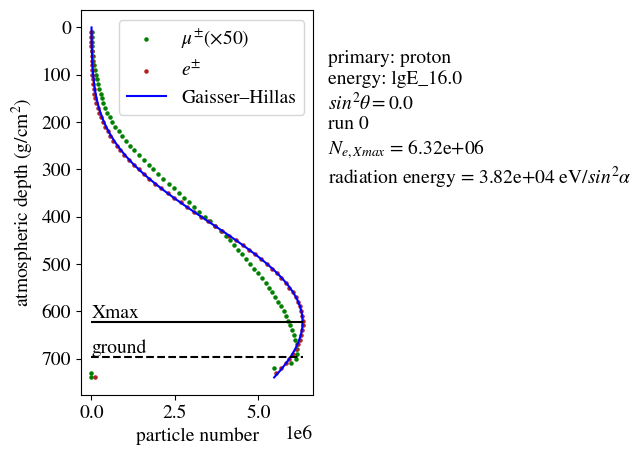

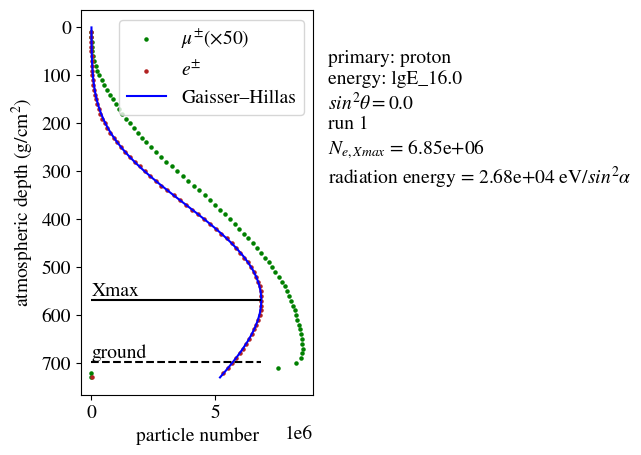

/tmp/ipykernel_669004/4135152285.py:2: RuntimeWarning: invalid value encountered in power
  return Nmax * ((X - X0) / (Xmax - X0)) ** ((Xmax - X0) / lamb) * np.exp((Xmax - X) / lamb)


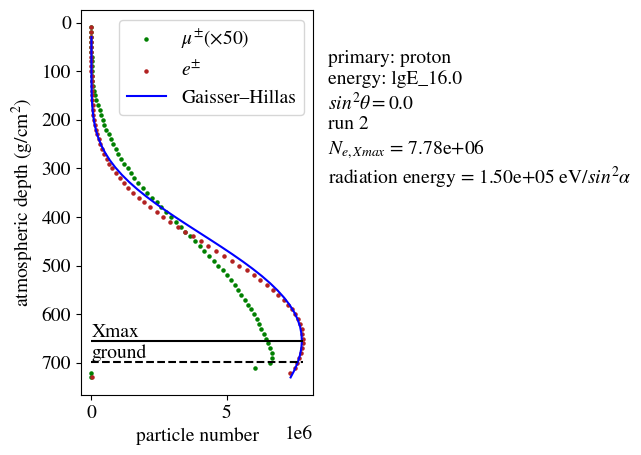

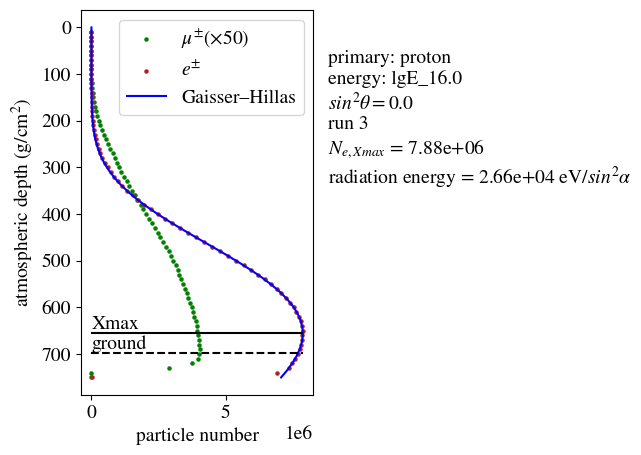

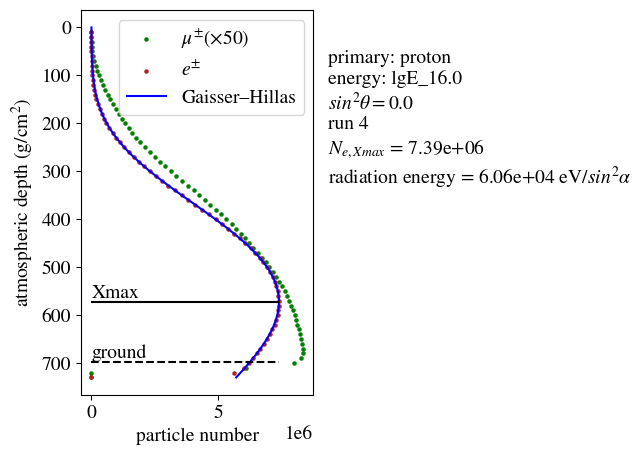

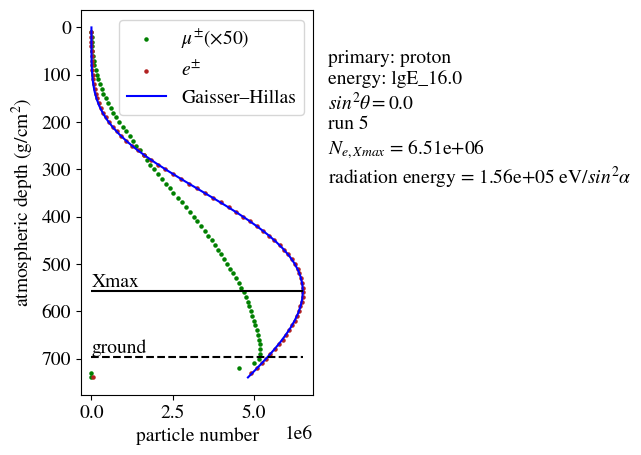

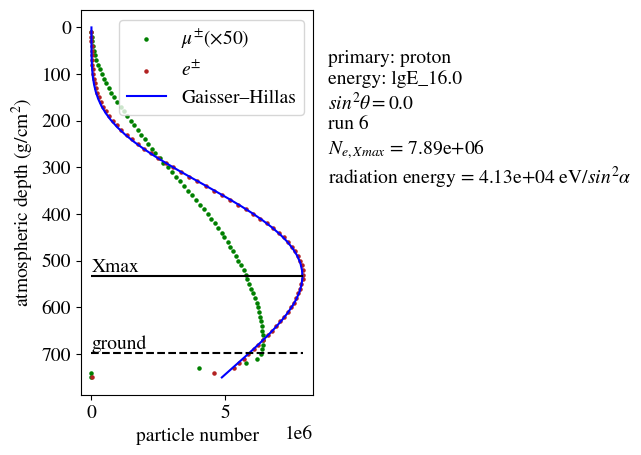

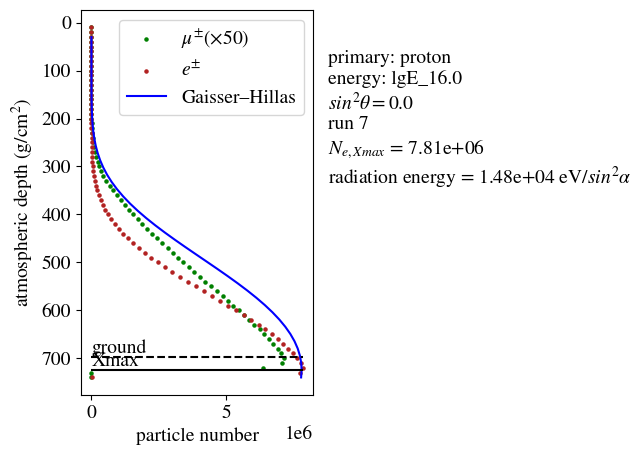

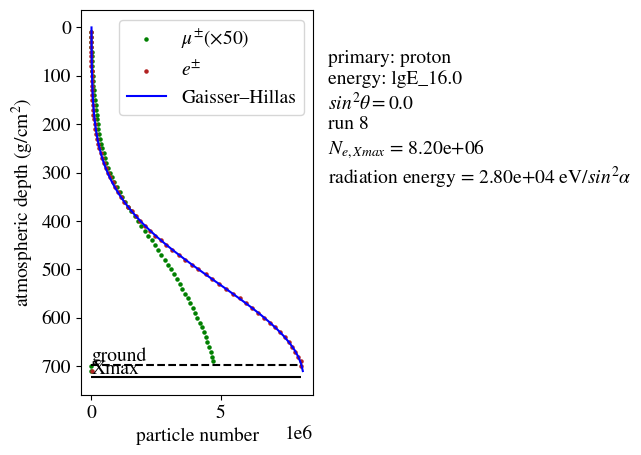

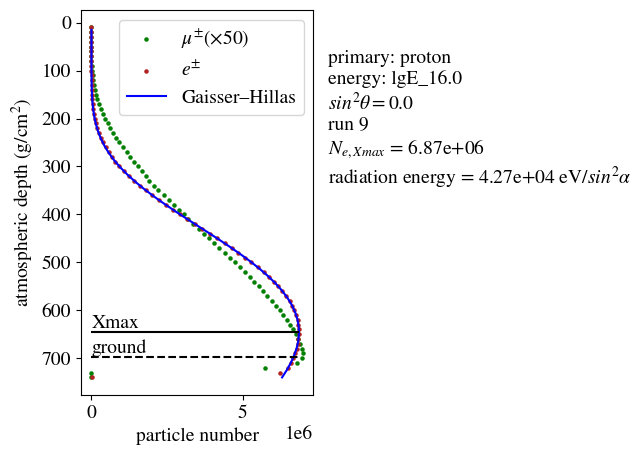

In [12]:
primary = "proton"
energy = "lgE_16.0"
sin2theta = "0.0"

plt.rcParams["font.size"] = 14
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})

for runnum in range(10):

    flong = fp_long(primary, energy, sin2theta, runnum)

    # load files

    numeric_lines = []

    with open(flong) as f:
        # skip first 2 rows
        for _ in range(2):
            next(f)

        for line in f:
            try:
                # try converting all columns to float
                [float(x) for x in line.split()]
                numeric_lines.append(line)
            except ValueError:
                break  # stop at first non-numeric row

    data = np.loadtxt(StringIO("".join(numeric_lines)))
    atmdepth = data[:,0]

    # extract data
    positron = data[:,2]
    electron = data[:,3]
    tot_e = positron + electron

    muplus = data[:,4]
    muminus = data[:,5]
    tot_mu = (muplus + muminus)*50

    # RadE data
    fRadE = fp_RadE_norm2(primary, energy, sin2theta)
    fileRadE = np.load(fRadE)
    RadE = fileRadE['radE(eV)'][runnum]

    # ground level
    X0 = 697.6 #g/cm^2
    thetafloat = float(sin2theta)
    costheta = np.cos(np.arcsin(np.sqrt(thetafloat)))
    Xv = X0/ costheta

    # fit parameters GH
    fXmax = f'Xmax/{primary}_{energy}_sin2_{sin2theta}.dat'
    fileXmax = np.loadtxt(fXmax)
    p0 = fileXmax[:,5][runnum]
    p1 = fileXmax[:,6][runnum]
    p2 = fileXmax[:,7][runnum]
    p3 = fileXmax[:,8][runnum]

    # Xmax data 

    Ne_Xmax = fileXmax[:,5][runnum]
    Xmax = fileXmax[:,6][runnum]


    # plot
    pltlp(atmdepth, positron, electron, muplus, muminus, tot_e, tot_mu, Xmax, Ne_Xmax, RadE, runnum, Xv, p0, p1, p2, p3)